In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from time import perf_counter 
import os
from keras.callbacks import ModelCheckpoint
from keras.models import load_model
from keras.utils import plot_model

In [31]:
## Defining batch specfications
batch_size = 100
img_height = 250
img_width = 250

In [32]:
## loading training set
training_data = tf.keras.preprocessing.image_dataset_from_directory(
    'data/train',
    seed=42,
    image_size= (img_height, img_width),
    batch_size=batch_size,
    color_mode='rgb'
)

Found 791 files belonging to 2 classes.


In [33]:
## loading validation dataset
validation_data =  tf.keras.preprocessing.image_dataset_from_directory(
    'data/val',
    seed=42,
    image_size= (img_height, img_width),
    batch_size=batch_size,
    color_mode='rgb'
)

Found 98 files belonging to 2 classes.


In [34]:
## loading testing dataset
testing_data = tf.keras.preprocessing.image_dataset_from_directory(
    'data/test',
    seed=42,
    image_size= (img_height, img_width),
    batch_size=batch_size,
    color_mode='rgb'
)

Found 100 files belonging to 2 classes.


In [35]:
testing_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 250, 250, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [36]:
class_names = training_data.class_names
class_names

['Accident', 'Non Accident']

In [37]:
## Configuring dataset for performance
AUTOTUNE = tf.data.experimental.AUTOTUNE
training_data = training_data.cache().prefetch(buffer_size=AUTOTUNE)
testing_data = testing_data.cache().prefetch(buffer_size=AUTOTUNE)

In [38]:
## Defining Cnn
model = tf.keras.models.Sequential([
  layers.BatchNormalization(),
  layers.Conv2D(32, 3, activation='relu'), # Conv2D(f_size, filter_size, activation) # relu, sigmoid, softmax
  layers.MaxPooling2D(), # MaxPooling
  layers.Conv2D(64, 3, activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(128, 3, activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(256, 3, activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(512, activation='relu'),
  layers.Dense(len(class_names), activation= 'softmax')
])

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [39]:
model.build((None, 250, 250, 3))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_1           │ (None, 250, 250, 3)    │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 248, 248, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 124, 124, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 122, 122, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 59, 59, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 29, 29, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 27, 27, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    22,151,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,541,134 (85.99 MB)

 Trainable params: 22,541,128 (85.99 MB)

 Non-trainable params: 6 (24.00 B)

In [40]:
plot_model(model, show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [41]:
## lets train our CNN
checkpoint = ModelCheckpoint("model_weights.h5", monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
callbacks_list = [checkpoint]
history = model.fit(training_data, validation_data=validation_data, epochs = 20, callbacks=callbacks_list)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5198 - loss: 5.4968
Epoch 1: val_accuracy improved from None to 0.53061, saving model to model_weights.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 67s 7s/step - accuracy: 0.5019 - loss: 3.6179 - val_accuracy: 0.5306 - val_loss: 0.6827
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5567 - loss: 0.6857
Epoch 2: val_accuracy did not improve from 0.53061
8/8 ━━━━━━━━━━━━━━━━━━━━ 53s 7s/step - accuracy: 0.5765 - loss: 0.6786 - val_accuracy: 0.5306 - val_loss: 0.8621
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6075 - loss: 0.6520
Epoch 3: val_accuracy improved from 0.53061 to 0.67347, saving model to model_weights.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 54s 7s/step - accuracy: 0.6384 - loss: 0.6322 - val_accuracy: 0.6735 - val_loss: 0.6203
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6732 - loss: 0.5883
Epoch 4: val_accuracy improved from 0.67347 to 0.69388, saving model to model_weights.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 48s 6s/step - accuracy: 0.6979 - loss: 0.5634 - val_accuracy: 0.6939 - val_loss: 0.5795
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7443 - loss: 0.5206
Epoch 5: val_accuracy did not improve from 0.69388
8/8 ━━━━━━━━━━━━━━━━━━━━ 47s 6s/step - accuracy: 0.7611 - loss: 0.4996 - val_accuracy: 0.6939 - val_loss: 0.5545
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7756 - loss: 0.4412
Epoch 6: val_accuracy improved from 0.69388 to 0.71429, saving model to model_weights.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 53s 7s/step - accuracy: 0.7914 - loss: 0.4197 - val_accuracy: 0.7143 - val_loss: 0.5827
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8397 - loss: 0.3539
Epoch 7: val_accuracy improved from 0.71429 to 0.73469, saving model to model_weights.h5


...

8/8 ━━━━━━━━━━━━━━━━━━━━ 52s 7s/step - accuracy: 0.9368 - loss: 0.1537 - val_accuracy: 0.8367 - val_loss: 0.7256
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9331 - loss: 0.1519
Epoch 12: val_accuracy did not improve from 0.83673
8/8 ━━━━━━━━━━━━━━━━━━━━ 57s 7s/step - accuracy: 0.9469 - loss: 0.1317 - val_accuracy: 0.8061 - val_loss: 0.7015
Epoch 13/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9649 - loss: 0.1116
Epoch 13: val_accuracy did not improve from 0.83673
8/8 ━━━━━━━━━━━━━━━━━━━━ 55s 7s/step - accuracy: 0.9709 - loss: 0.0935 - val_accuracy: 0.8367 - val_loss: 0.7251
Epoch 14/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9673 - loss: 0.0886
Epoch 14: val_accuracy did not improve from 0.83673
8/8 ━━━━━━━━━━━━━━━━━━━━ 55s 7s/step - accuracy: 0.9772 - loss: 0.0705 - val_accuracy: 0.8367 - val_loss: 0.7429
Epoch 15/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9766 - loss: 0.0770
Epoch 15: val_accuracy improved from 0.83673 to 0.84694, saving 

8/8 ━━━━━━━━━━━━━━━━━━━━ 54s 7s/step - accuracy: 0.9836 - loss: 0.0589 - val_accuracy: 0.8469 - val_loss: 0.6904
Epoch 16/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9793 - loss: 0.0555
Epoch 16: val_accuracy improved from 0.84694 to 0.87755, saving model to model_weights.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 53s 7s/step - accuracy: 0.9848 - loss: 0.0517 - val_accuracy: 0.8776 - val_loss: 0.6408
Epoch 17/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9708 - loss: 0.0880
Epoch 17: val_accuracy did not improve from 0.87755
8/8 ━━━━━━━━━━━━━━━━━━━━ 51s 6s/step - accuracy: 0.9785 - loss: 0.0620 - val_accuracy: 0.8367 - val_loss: 0.5432
Epoch 18/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9763 - loss: 0.0448
Epoch 18: val_accuracy did not improve from 0.87755
8/8 ━━━━━━━━━━━━━━━━━━━━ 80s 6s/step - accuracy: 0.9810 - loss: 0.0478 - val_accuracy: 0.8571 - val_loss: 0.7005
Epoch 19/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9817 - loss: 0.0639
Epoch 19: val_accuracy improved from 0.87755 to 0.88776, saving model to model_weights.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 50s 6s/step - accuracy: 0.9848 - loss: 0.0530 - val_accuracy: 0.8878 - val_loss: 0.3132
Epoch 20/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9720 - loss: 0.0652
Epoch 20: val_accuracy improved from 0.88776 to 0.89796, saving model to model_weights.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 52s 7s/step - accuracy: 0.9709 - loss: 0.0678 - val_accuracy: 0.8980 - val_loss: 0.5638


In [ ]:
###### serialize model structure to JSON
model_json = model.to_json()
with open("model.json", "w") as json_file:
    json_file.write(model_json)

: 

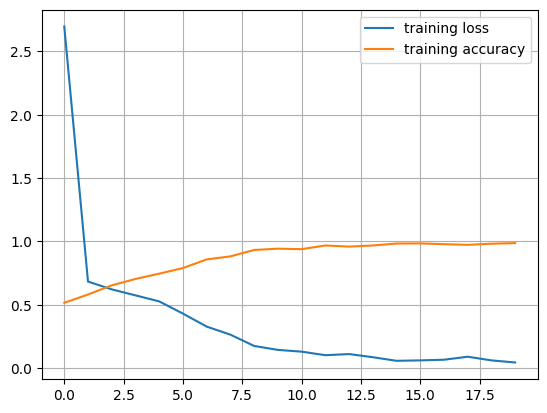

: 

In [ ]:
## stats on training data
plt.plot(history.history['loss'], label = 'training loss')
plt.plot(history.history['accuracy'], label = 'training accuracy')
plt.grid(True)
plt.legend()

In [ ]:
## stats on training data
plt.plot(history.history['val_loss'], label = 'validation loss')
plt.plot(history.history['val_accuracy'], label = 'validation accuracy')
plt.grid(True)
plt.legend()

: 

In [ ]:
## lets vizualize results on testing data
AccuracyVector = []
plt.figure(figsize=(30, 30))
for images, labels in testing_data.take(1):
    predictions = model.predict(images)
    predlabel = []
    prdlbl = []
    
    for mem in predictions:
        predlabel.append(class_names[np.argmax(mem)])
        prdlbl.append(np.argmax(mem))
    
    AccuracyVector = np.array(prdlbl) == labels
    for i in range(40):
        ax = plt.subplot(10, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title('Pred: '+ predlabel[i]+' actl:'+class_names[labels[i]] )
        plt.axis('off')
        plt.grid(True)

: 